# Phase 2 — Exploratory Data Analysis & Visualization
**Capstone 1 | Phases 1–5**

Class distributions, feature correlation heatmap, boxplots by label, and word clouds for AI vs. Human text.

**Key finding:** `predictability_score`, `burstiness`, and `grammar_errors` show suspiciously clean class separation — flagging the dataset as synthetic.

**Loads:** `outputs/df_cleaned.pkl`  
**Next:** `phase3_feature_engineering.ipynb`


In [ ]:
import numpy as np, random, os
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
try:
    import torch
    torch.manual_seed(RANDOM_SEED); torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
    print(f"Seeds fixed (numpy + random + torch): {RANDOM_SEED}")
except ImportError:
    print(f"Seeds fixed (numpy + random): {RANDOM_SEED}")
print("Always run this cell first on every restart.")


In [ ]:
import joblib
df = joblib.load('outputs/df_cleaned.pkl')
print(f"Loaded df: {df.shape}")


/tmp/ipython-input-3217759345.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#3498db', '#e74c3c'])


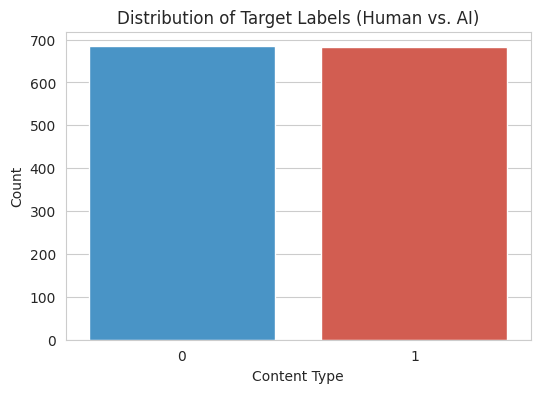

/tmp/ipython-input-3217759345.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='content_type', data=df, order=df['content_type'].value_counts().index, palette='viridis')


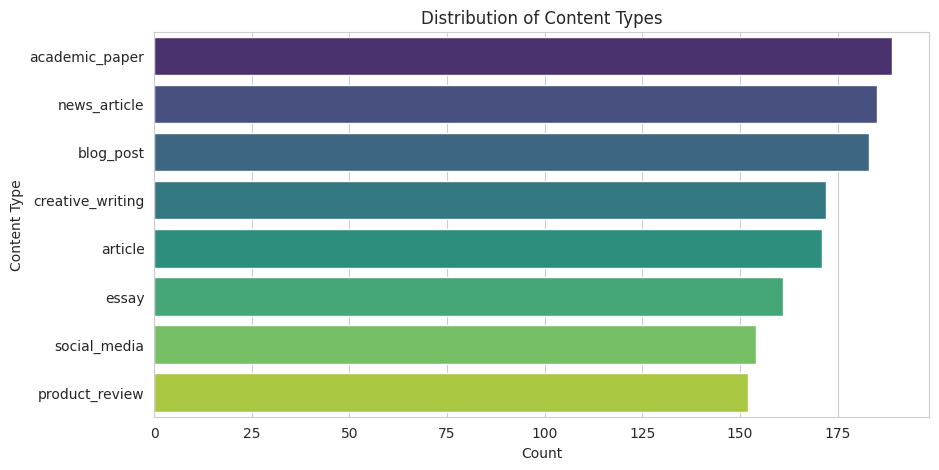

/tmp/ipython-input-3217759345.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette=['#3498db', '#e74c3c'])
/tmp/ipython-input-3217759345.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette=['#3498db', '#e74c3c'])
/tmp/ipython-input-3217759345.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette=['#3498db', '#e74c3c'])
/tmp/ipython-input-3217759345.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated

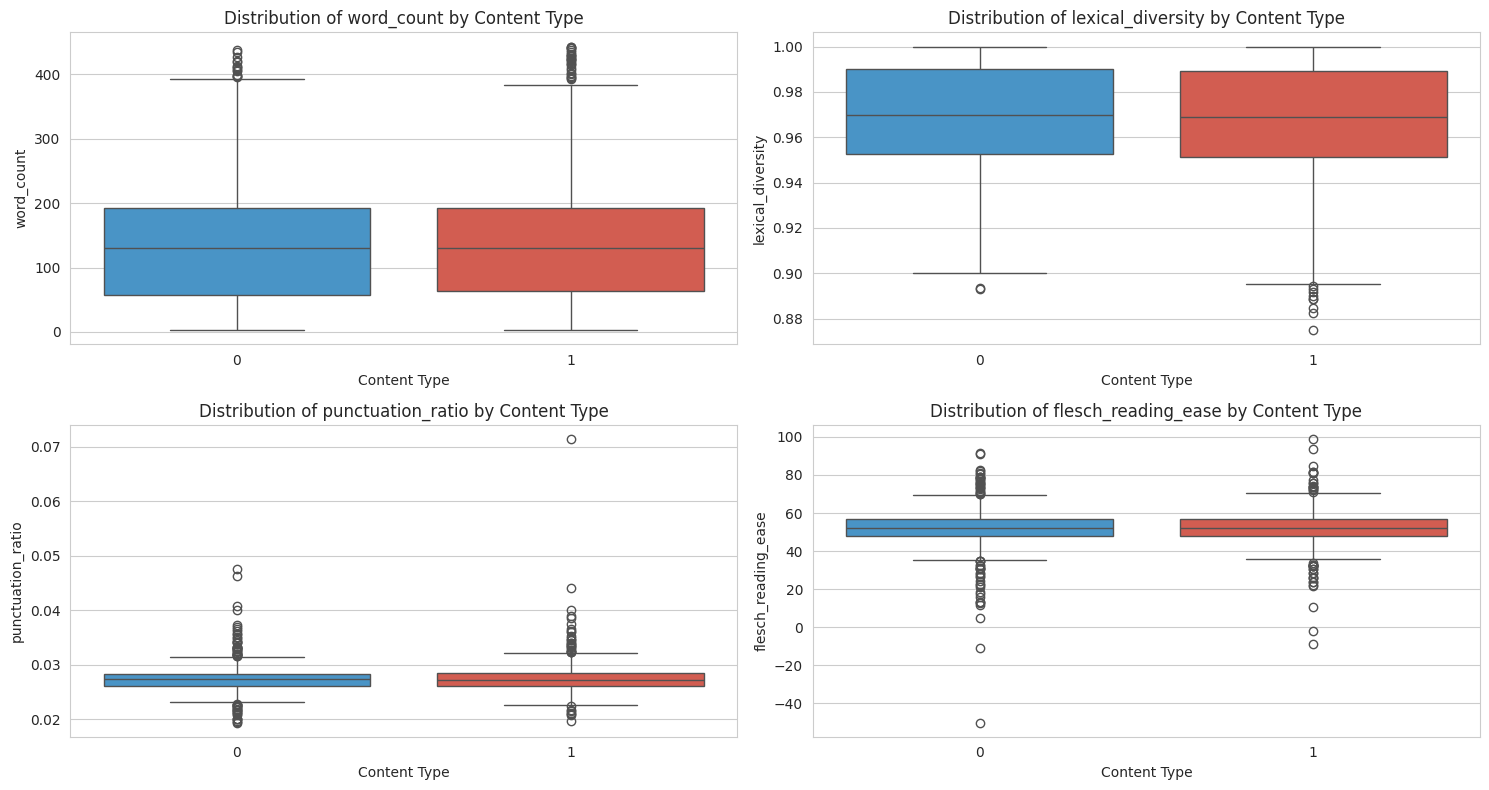

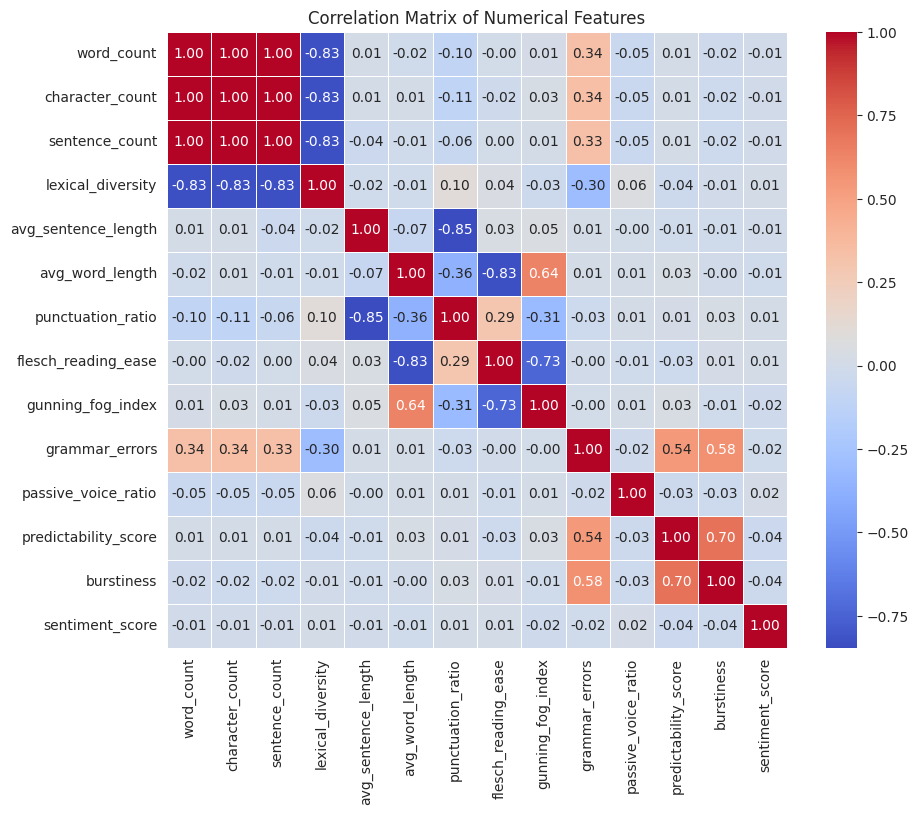

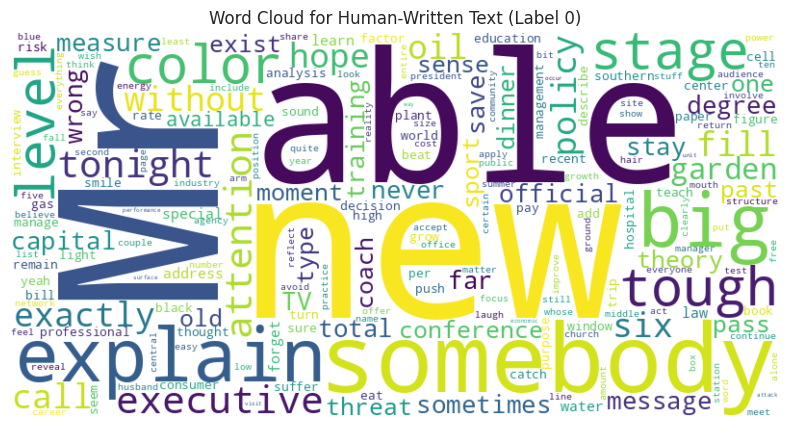

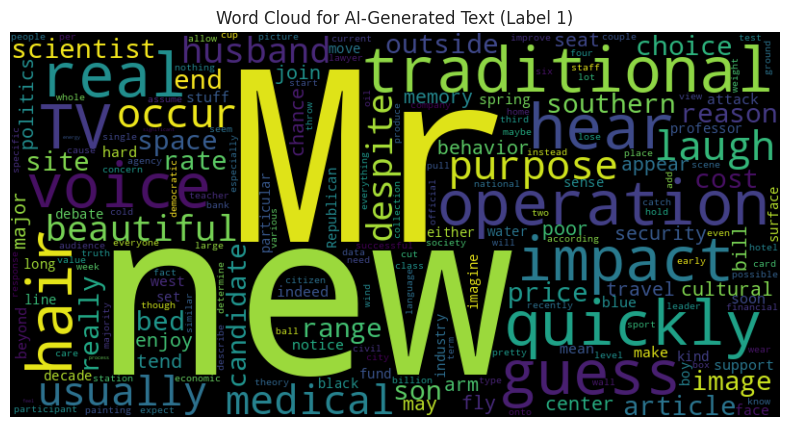

In [ ]:
from wordcloud import WordCloud
# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette=['#3498db', '#e74c3c'])
plt.title('Distribution of Target Labels (Human vs. AI)')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

# Content Type Distribution
if 'content_type' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(y='content_type', data=df, order=df['content_type'].value_counts().index, palette='viridis')
    plt.title('Distribution of Content Types')
    plt.xlabel('Count')
    plt.ylabel('Content Type')
    plt.show()

# Key Numerical Feature Distributions by Target Class (Box Plots)
analysis_features = ['word_count', 'lexical_diversity', 'punctuation_ratio', 'flesch_reading_ease']

plt.figure(figsize=(15, 8))
for i, feature in enumerate(analysis_features):
    if feature in df.columns:
        plt.subplot(2, 2, i + 1)
        sns.boxplot(x='label', y=feature, data=df, palette=['#3498db', '#e74c3c'])
        plt.title(f'Distribution of {feature} by Content Type')
        plt.xlabel('Content Type')

plt.tight_layout()
plt.show()

# Correlation Heatmap of Numerical Features
numerical_df = df[numerical_features]
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=".5")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


human_text = " ".join(df[df[TARGET_COLUMN] == 0]['text_content'].astype(str))
ai_text = " ".join(df[df[TARGET_COLUMN] == 1]['text_content'].astype(str))


# Word clouds
wordcloud_human = WordCloud(width=800, height=400, background_color='white').generate(human_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_human, interpolation='bilinear')
plt.title('Word Cloud for Human-Written Text (Label 0)')
plt.axis('off')
plt.show()

wordcloud_ai = WordCloud(width=800, height=400, background_color='black', colormap='viridis').generate(ai_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_ai, interpolation='bilinear')
plt.title('Word Cloud for AI-Generated Text (Label 1)')
plt.axis('off')
plt.show()

The distinct separation of features like predictability score, burstiness, and grammar errors by label, along with the specific distribution of content types, strongly suggests that the dataset is synthetic or heavily curated.